# Data Cleaning & Visualization Project
**Goal:** Take a raw, messy retail sales dataset, clean it, and produce a visual dashboard of key insights.

**Dataset:** Synthetic retail sales export (1,225 raw rows) with realistic real-world data-quality issues:
- Missing values (Region, PaymentMethod, UnitPrice, CustomerRating)
- Duplicate order records
- Outliers in price and quantity
- Inconsistent text casing (`electronics` vs `Electronics` vs `ELECTRONICS `)
- Mixed date formats (`YYYY-MM-DD`, `DD/MM/YYYY`, `MM-DD-YYYY`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)


## 1. Load raw data & first look

In [2]:
df = pd.read_csv("raw_sales_data.csv")
print(df.shape)
df.head()


(1225, 8)


,OrderID,OrderDate,Category,Region,PaymentMethod,Quantity,UnitPrice,CustomerRating
0,ORD1686,2025-01-22,Electronics,South,UPI,3,8289.18,3.6
1,ORD2149,20/12/2025,sports,East,Credit Card,3,1635.33,2.6
2,ORD1159,03-08-2025,Home and Kitchen,South,Debit Card,1,2503.76,4.9
3,ORD1915,11-19-2025,Books,South,Credit Card,1,515.80,2.6
4,ORD1341,2025-12-26,Home & Kitchen,North,Debit Card,1,3493.89,4.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         1225 non-null   str    
 1   OrderDate       1225 non-null   str    
 2   Category        1225 non-null   str    
 3   Region          1175 non-null   str    
 4   PaymentMethod   1201 non-null   str    
 5   Quantity        1225 non-null   int64  
 6   UnitPrice       1188 non-null   float64
 7   CustomerRating  1128 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 76.7 KB


In [4]:
print("Missing values per column:")
df.isna().sum()


Missing values per column:


OrderID            0
OrderDate          0
Category           0
Region            50
PaymentMethod     24
Quantity           0
UnitPrice         37
CustomerRating    97
dtype: int64

## 2. Standardize text columns
Category values arrived in inconsistent casing/whitespace — normalize them.

In [5]:
print("Before:", sorted(df['Category'].unique()))
df["Category"] = df["Category"].str.strip().str.title()
df["Category"] = df["Category"].replace({"Home And Kitchen": "Home & Kitchen"})
print("After:", sorted(df['Category'].unique()))


Before: [' Sports', 'BEAUTY', 'Beauty', 'Books', 'Books ', 'Clothing', 'Clothing ', 'ELECTRONICS', 'Electronics', 'Electronics ', 'Home & Kitchen', 'Home and Kitchen', 'Sports', 'beauty', 'books', 'clothing', 'electronics', 'home & kitchen', 'sports']
After: ['Beauty', 'Books', 'Clothing', 'Electronics', 'Home & Kitchen', 'Sports']


## 3. Parse mixed date formats

In [6]:
def parse_date(s):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df["OrderDate"] = df["OrderDate"].apply(parse_date)
print("Unparsed dates:", df["OrderDate"].isna().sum())


Unparsed dates: 0


## 4. Remove duplicate rows

In [7]:
before = len(df)
df = df.drop_duplicates(subset=["OrderID", "OrderDate", "Category", "Region", "Quantity", "UnitPrice"])
print(f"Removed {before - len(df)} duplicate rows -> {len(df)} rows remain")


Removed 25 duplicate rows -> 1200 rows remain

## 5. Handle missing values
- `Region` / `PaymentMethod` (categorical) → fill with `"Unknown"` / mode
- `CustomerRating` (numeric, roughly symmetric) → median
- `UnitPrice` (numeric, varies a lot by category) → **median within each category**, not the global median


In [8]:
df["Region"] = df["Region"].fillna("Unknown")
df["PaymentMethod"] = df["PaymentMethod"].fillna(df["PaymentMethod"].mode()[0])
df["CustomerRating"] = df["CustomerRating"].fillna(df["CustomerRating"].median())
df["UnitPrice"] = df.groupby("Category")["UnitPrice"].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", int(df.isna().sum().sum()))


Remaining missing values: 0


## 6. Handle outliers (IQR method)
`UnitPrice` naturally differs a lot by category (Books vs Electronics), so outlier
bounds are computed **per category** rather than globally — otherwise normal
high-value Electronics orders would be wrongly flagged and squashed.


In [9]:
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    capped = series.clip(lower, upper)
    return capped, int((series != capped).sum()), lower, upper

total_capped = 0
for cat, group in df.groupby("Category"):
    capped, n_capped, lo, hi = cap_outliers_iqr(group["UnitPrice"])
    df.loc[group.index, "UnitPrice"] = capped
    total_capped += n_capped
    print(f"  {cat:<16} capped {n_capped:>2} outliers -> range [{lo:,.0f}, {hi:,.0f}]")
print(f"Total UnitPrice outliers capped: {total_capped}")

df["Quantity"], n_qty, lo_q, hi_q = cap_outliers_iqr(df["Quantity"])
df["Quantity"] = df["Quantity"].clip(lower=1).round().astype(int)
print(f"Quantity outliers capped: {n_qty} -> range [{max(lo_q,1):.0f}, {hi_q:.0f}]")


  Beauty           capped  4 outliers -> range [376, 1,488]
  Books            capped  2 outliers -> range [140, 746]
  Clothing         capped  3 outliers -> range [313, 2,089]
  Electronics      capped  6 outliers -> range [3,383, 14,231]
  Home & Kitchen   capped  5 outliers -> range [810, 4,249]
  Sports           capped  4 outliers -> range [637, 3,025]
Total UnitPrice outliers capped: 24
Quantity outliers capped: 10 -> range [1, 7]


## 7. Feature engineering

In [10]:
df["Revenue"] = (df["Quantity"] * df["UnitPrice"]).round(2)
df["Month"] = df["OrderDate"].dt.to_period("M").astype(str)
df.to_csv("cleaned_sales_data.csv", index=False)
df.head()


,OrderID,OrderDate,Category,Region,PaymentMethod,Quantity,UnitPrice,CustomerRating,Revenue,Month
0,ORD1686,2025-01-22,Electronics,South,UPI,3,8289.18,3.6,24867.54,2025-01
1,ORD2149,2025-12-20,Sports,East,Credit Card,3,1635.33,2.6,4905.99,2025-12
2,ORD1159,2025-03-08,Home & Kitchen,South,Debit Card,1,2503.76,4.9,2503.76,2025-03
3,ORD1915,2025-11-19,Books,South,Credit Card,1,515.80,2.6,515.80,2025-11
4,ORD1341,2025-12-26,Home & Kitchen,North,Debit Card,1,3493.89,4.0,3493.89,2025-12


## 8. Exploratory summary

In [11]:
summary = {
    "Total orders": len(df),
    "Total revenue (₹)": round(df["Revenue"].sum(), 2),
    "Average order value (₹)": round(df["Revenue"].mean(), 2),
    "Average customer rating": round(df["CustomerRating"].mean(), 2),
    "Top category by revenue": df.groupby("Category")["Revenue"].sum().idxmax(),
    "Top region by orders": df["Region"].value_counts().idxmax(),
}
for k, v in summary.items():
    print(f"{k:<28}: {v}")


Total orders                : 1200
Total revenue (₹)           : 11385128.01
Average order value (₹)     : 9487.61
Average customer rating     : 3.97
Top category by revenue     : Electronics
Top region by orders        : North


## 9. Visualization dashboard

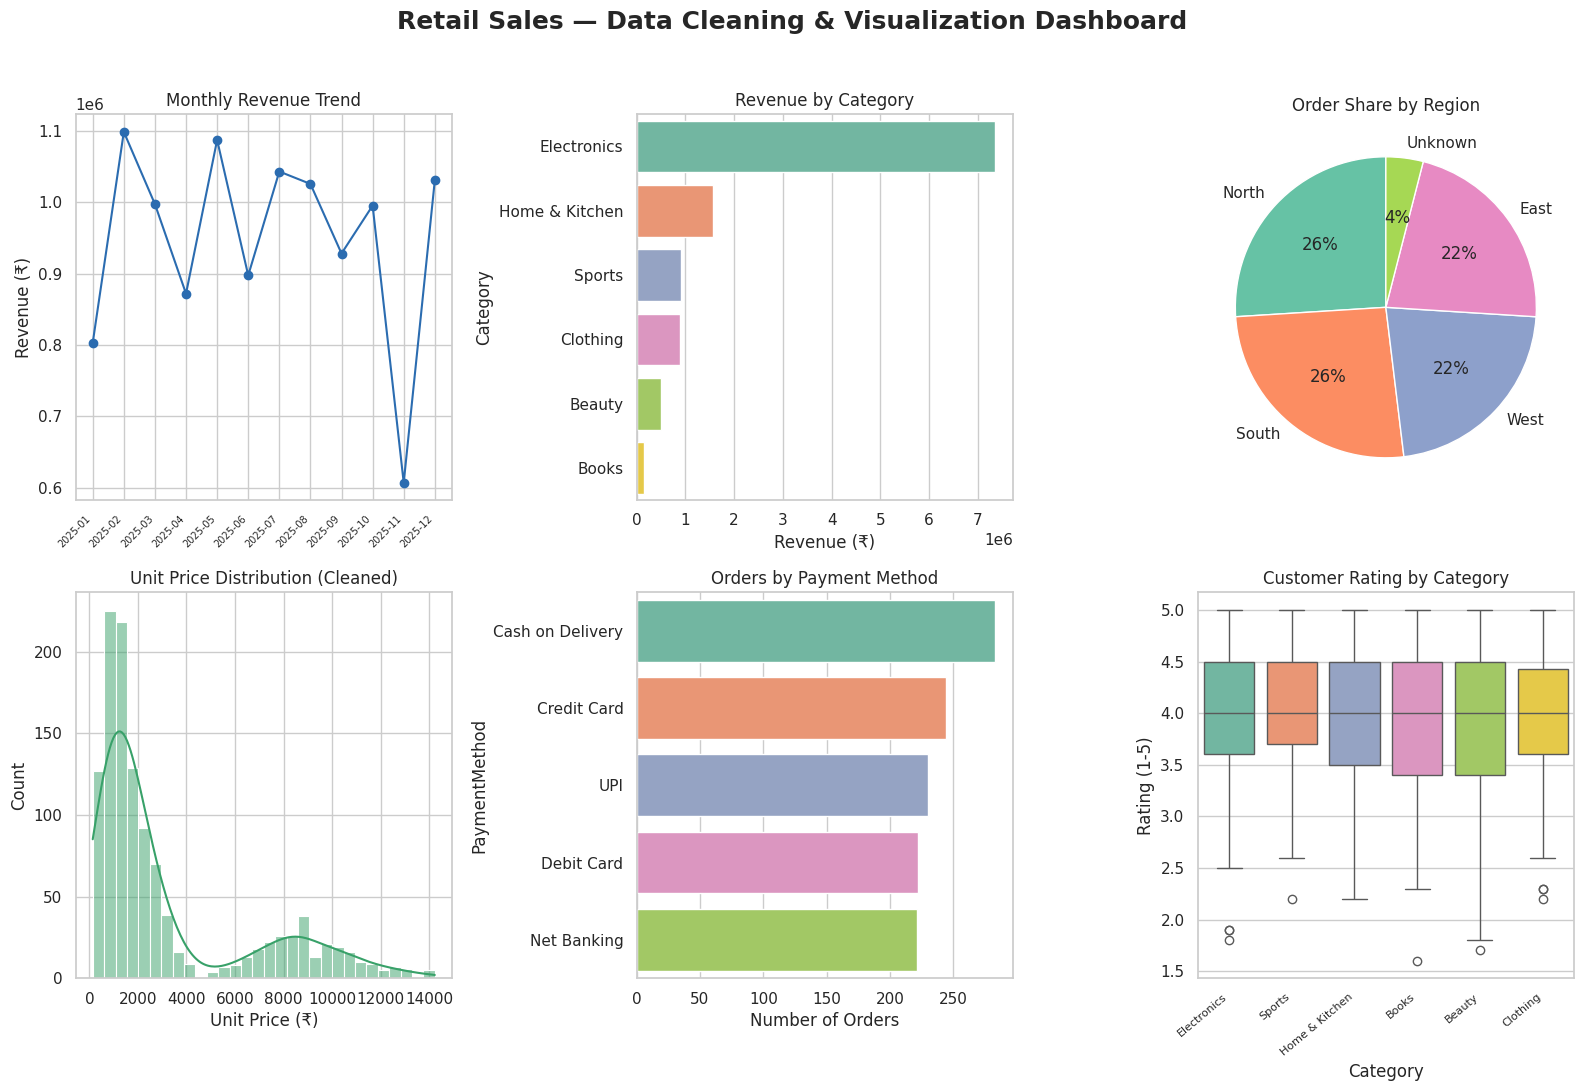

In [12]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle("Retail Sales — Data Cleaning & Visualization Dashboard", fontsize=18, fontweight="bold", y=0.99)

ax1 = plt.subplot(2, 3, 1)
monthly = df.groupby("Month")["Revenue"].sum().sort_index()
ax1.plot(monthly.index, monthly.values, marker="o", color="#2b6cb0")
ax1.set_title("Monthly Revenue Trend")
ax1.set_xticks(range(len(monthly.index)))
ax1.set_xticklabels(monthly.index, rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Revenue (₹)")

ax2 = plt.subplot(2, 3, 2)
cat_rev = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, ax=ax2, hue=cat_rev.index, legend=False)
ax2.set_title("Revenue by Category")
ax2.set_xlabel("Revenue (₹)")

ax3 = plt.subplot(2, 3, 3)
region_counts = df["Region"].value_counts()
ax3.pie(region_counts.values, labels=region_counts.index, autopct="%1.0f%%", startangle=90, colors=sns.color_palette("Set2"))
ax3.set_title("Order Share by Region")

ax4 = plt.subplot(2, 3, 4)
sns.histplot(df["UnitPrice"], bins=30, kde=True, ax=ax4, color="#38a169")
ax4.set_title("Unit Price Distribution (Cleaned)")
ax4.set_xlabel("Unit Price (₹)")

ax5 = plt.subplot(2, 3, 5)
pay_counts = df["PaymentMethod"].value_counts()
sns.barplot(x=pay_counts.values, y=pay_counts.index, ax=ax5, hue=pay_counts.index, legend=False)
ax5.set_title("Orders by Payment Method")
ax5.set_xlabel("Number of Orders")

ax6 = plt.subplot(2, 3, 6)
sns.boxplot(data=df, x="Category", y="CustomerRating", ax=ax6, hue="Category", legend=False)
ax6.set_title("Customer Rating by Category")
ax6.set_xticks(range(len(ax6.get_xticklabels())))
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=40, ha="right", fontsize=8)
ax6.set_ylabel("Rating (1-5)")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("dashboard.png", dpi=150)
plt.show()


## 10. Key findings
- **Electronics** drives the largest share of revenue by a wide margin, despite not having the most orders — its higher price point matters more than volume.
- **North** and **South** regions each account for roughly a quarter of orders; the small `Unknown` slice is the residual of originally-missing `Region` values.
- **Cash on Delivery** and **Credit Card** are the two most common payment methods.
- Unit prices are right-skewed with a small secondary cluster around ₹8,000–10,000 — mostly Electronics orders.
- Median customer ratings sit around 4.0 across all categories, with **Beauty** and **Books** showing slightly wider spread (more low-rating outliers).
- Cleaning removed 25 duplicate rows and imputed 204 missing values across four columns, and capped a small number of genuine per-category price/quantity outliers using the IQR method rather than a single global threshold.
